In [3]:
from openpyxl import Workbook
from openpyxl import load_workbook
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os
import itertools
from datetime import datetime
import joblib
from scipy import stats
from sklearn.decomposition import PCA
#from tqdm.notebook import tqdm
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from matplotlib import font_manager as fm
import openpyxl
import shutil
import subprocess
import seaborn as sns

In [5]:
import logging
import os
from datetime import datetime


# 로그 생성
logger = logging.getLogger()

# 로그의 출력 기준 설정
logger.setLevel(logging.INFO)

# log 출력 형식
formatter = logging.Formatter('%(asctime)s[%(levelname)s]: %(message)s')

while logger.hasHandlers():
    logger.removeHandler(logger.handlers[0])
    
    
# log 출력
stream_handler = logging.StreamHandler()
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)


In [ ]:
df_exp = pd.read_csv(f'SST_PV_cfos_Summary_Jin_Mehdi_March25_EXP.csv')
df_veh = pd.read_csv(f'SST_PV_cfos_Summary_Jin_Mehdi_March25_VEH.csv')

In [ ]:
def proprocess(_df):        
    _df = _df.drop([a for a in _df.columns if a.startswith("Unnamed")], axis=1)
    _df = _df.drop([a for a in _df.columns if a.startswith("average")], axis=1)
    _df = _df.drop([a for a in _df.columns if a.startswith("sem")], axis=1)
    _df = _df.drop([a for a in _df.columns if a.startswith("%error")], axis=1)
    #df_exp = df_exp.drop([a for a in df_exp.columns if a.endswith("fraction")], axis=1)
    _df.drop(_df[_df['TG number'] == 1329].index, inplace=True)
    _df['Region ID'] = _df['Region ID'].astype(int)
    _df['TG number'] = _df['TG number'].astype(int)
    for _c in _df.columns:
        if _c.endswith('SS/cfos fraction'):
            _df = _df.rename(columns={_c: _c.replace('SS/cfos fraction','SST/cfos fraction')})
            
    _df = _df.replace('#DIV/0!',0.0)
    for _c in _df.columns[3:]:
        _df[_c] = _df[_c].astype(float)
    return _df

In [ ]:
df_exp = proprocess(df_exp)
df_veh = proprocess(df_veh)

In [ ]:
df_exp

In [ ]:
print(len(df_exp))
print(len(df_veh))

In [ ]:
print("the number of regions with all zero")

df_exp_zeros = df_exp[df_exp[df_exp.columns[3:]].sum(axis=1) == 0.0]
df_veh_zeros = df_veh[df_veh[df_veh.columns[3:]].sum(axis=1) == 0.0]

print(len(df_exp_zeros))
print(len(df_veh_zeros))


In [ ]:
df_exp_zeros['Region ID']

In [ ]:
zero_region_ids_exp_1_veh_1 = list(set(df_exp_zeros['Region ID'].values).intersection(set(df_veh_zeros['Region ID'].values)))
zero_region_ids_exp_1_veh_0 = list(set(df_exp_zeros['Region ID'].values).difference(set(df_veh_zeros['Region ID'].values)))
zero_region_ids_exp_0_veh_1 = list(set(df_veh_zeros['Region ID'].values).difference(set(df_exp_zeros['Region ID'].values)))
print(len(zero_region_ids_exp_1_veh_1))
print(len(zero_region_ids_exp_1_veh_0),zero_region_ids_exp_1_veh_0)
print(len(zero_region_ids_exp_0_veh_1),zero_region_ids_exp_0_veh_1)


In [ ]:
zero_region_ids_exp_1_veh_1 = list(set(df_exp_zeros.index).intersection(set(df_veh_zeros.index)))
zero_region_ids_exp_1_veh_0 = list(set(df_exp_zeros.index).difference(set(df_veh_zeros.index)))
zero_region_ids_exp_0_veh_1 = list(set(df_veh_zeros.index).difference(set(df_exp_zeros.index)))
print(len(zero_region_ids_exp_1_veh_1))
print(len(zero_region_ids_exp_1_veh_0),zero_region_ids_exp_1_veh_0)
print(len(zero_region_ids_exp_0_veh_1),zero_region_ids_exp_0_veh_1)


In [ ]:
print(df_exp[df_exp['Region ID'].isin(zero_region_ids_exp_1_veh_0)]['Region name'])
print(df_veh[df_veh['Region ID'].isin(zero_region_ids_exp_0_veh_1)]['Region name'])

#print(df_veh.loc[zero_region_ids_exp_0_veh_1]['Region name'])

In [ ]:
tg_2_name = {}
for _i, _row in df_exp[['TG number','Region name']].iterrows():
    tg_2_name[_row['TG number']] = _row['Region name']
tg_2_name

In [ ]:
#df_exp = df_exp[~df_exp['Region ID'].isin(zero_region_ids_exp_1_veh_1)]
#df_veh = df_veh[~df_veh['Region ID'].isin(zero_region_ids_exp_1_veh_1)]
#print(len(df_exp))
#print(len(df_veh))

In [ ]:
subject_id_exp = list(set([a.split("_")[0] for a in df_exp.columns[3:]]))
subject_id_veh = list(set([a.split("_")[0] for a in df_veh.columns[3:]]))
print(subject_id_exp)
print(subject_id_veh)

In [ ]:
cut_method_list = list(set([a.split("_")[1] for a in df_exp.columns[3:]]))
color_list = list(set([a.split("_")[2] for a in df_exp.columns[3:]]))

print(cut_method_list)
print(color_list)

#color_list = ['PV','cfos','SST']

In [306]:
df_total = pd.concat([df_exp.drop(['TG number','Region ID','Region name'] ,axis=1),df_veh.drop(['Region ID','Region name'] ,axis=1)], axis=1)
df_total.set_index('TG number', inplace=True)
df_total = df_total.T
df_total['veh_exp'] = [1 if a.split('_')[0] in subject_id_exp else 0 for a in df_total.index]
df_total['cut_method'] = ['cor' if a.split('_')[1] == 'cor' else 'sag' for a in df_total.index]
df_total['color'] =[ a.split('_')[2] for a in df_total.index]

In [ ]:
from itertools import product

dept_columns = []
for _a in list(product(cut_method_list, color_list)):
    dept_columns.append("_".join(_a))
dept_columns
 

In [571]:
sorted(color_list)

['PV',
 'PV-cfos',
 'PV/cfos fraction',
 'SST',
 'SST-PV',
 'SST-PV-cfos',
 'SST-PV/cfos fraction',
 'SST-cfos',
 'SST/cfos fraction',
 'cfos',
 'cfos total']

In [576]:
_df_vis

,A0245_cor_PV/cfos fraction,A0245_sag_PV/cfos fraction,A0247_cor_PV/cfos fraction,A0247_sag_PV/cfos fraction,A0249_cor_PV/cfos fraction,A0249_sag_PV/cfos fraction,A0244_cor_PV/cfos fraction,A0244_sag_PV/cfos fraction,A0242_cor_PV/cfos fraction,A0242_sag_PV/cfos fraction,1049_cor_PV/cfos fraction,1049_sag_PV/cfos fraction
TG number,,,,,,,,,,,,
Clear Label,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
root,13.528807,0.846262,1.994092,9.894548,3.014133,53.052848,0.241918,1.101906,1.57385,3.691275,20.06263,25.892697
Basic cell groups and regions,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
Cerebrum,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
Cerebral cortex,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
intraparafloccular fissure,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
paramedian sulcus,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
parafloccular sulcus,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000


2024-12-13 20:49:41,075[INFO]: PV PV-cfos PV/cfos fraction
2024-12-13 20:49:46,829[INFO]: SST SST-cfos SST/cfos fraction
2024-12-13 20:49:52,611[INFO]: SST-PV SST-PV-cfos SST-PV/cfos fraction
2024-12-13 20:49:58,173[INFO]: cfos cfos total


<Figure size 640x480 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

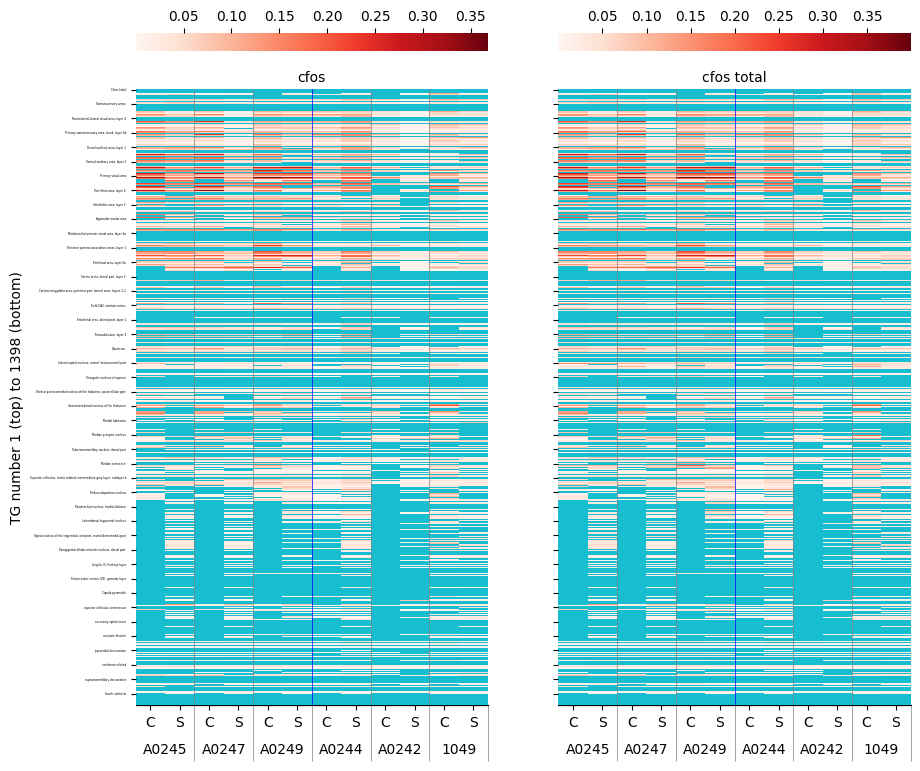

In [579]:
#fig = plt.figure(figsize = (10,30))

def draw_heatmap(_df_total, _color, ax):
    
    _df_vis = _df_total.query(f'color=="{_color}"').T
    _df_vis = _df_vis.loc[_df_vis.index[:-3]]
    for _c in _df_vis.columns:
        _df_vis[_c] = _df_vis[_c].astype(float)
    _df_vis = _df_vis.rename(index=tg_2_name)


    xticks_labels = []
    xticks = []
    subject_names = []
    subject_ids = []
    subject_sep_ids = []
    for _i in range(len(_df_vis.columns)):
        _name = _df_vis.columns[_i].split("_")
        xticks_labels.append(_name[1][0].upper())
        if _i % 2 == 0:
            
            subject_ids.append(_i+1)
            subject_sep_ids.append(_i+2)
            subject_names.append("\n\n" + _name[0])
        xticks.append(_i)

    
    
    _cmap = matplotlib.colormaps.get_cmap('Reds')
    _cmap.set_bad("tab:cyan")
    
    sns.heatmap(ax=ax, data = _df_vis, cmap=_cmap, rasterized=False, 
                cbar_kws = dict(use_gridspec=False,location="top"), mask=(_df_vis==0)) 
    
    #sns.move_legend(ax, "upper center")
    #fig.legend.set_bbox_to_anchor((0.6, 0.25))
    ax.set_title(_color, fontsize=10)

    if _color_index == 0:
        ax.set_ylabel("TG number 1 (top) to 1398 (bottom)",fontsize=10)
        _index_ids = []
        _index_names = []
        for _i in range(len(_df_vis.index)):
            if _i %2 == 0:
                _index_ids.append(_i)
                _index_names.append(list(_df_vis.index.values)[_i])
        
        ax.set_yticks(_index_ids)
        ax.set_yticklabels(_index_names, fontsize=2)
    else:
        ax.set_ylabel("")
        
    ax.set_xticklabels( xticks_labels, rotation = 0 )
    
    sec = ax.secondary_xaxis(location=0)
    sec.set_xticks(subject_ids, labels=subject_names)
    sec.tick_params('x', length=0)
    
    
    sec2 = ax.secondary_xaxis(location=0)
    sec2.set_xticks(subject_sep_ids, labels=[])
    sec2.tick_params('x', length=40, width=0.5, color='grey')
    
    
    #plt.annotate('Experimental', (0,0), (80, -60), xycoords='axes points', textcoords='offset points', va='top')
    #plt.annotate('Vehicle', (0,0), (310, -60), xycoords='axes points', textcoords='offset points', va='top')
    
    #ax.set(xlabel="", ylabel="")
    for i in range(len(_df_vis.columns)):
        if i == 0:
            continue
        elif i % 6 == 0:
            ax.axvline(i, color='blue', lw=0.5)
        elif i % 2 == 0:
            ax.axvline(i, color='grey', lw=0.5)
    #plt.legend(loc='upper center')




_color_list = [['PV', 'PV-cfos', 'PV/cfos fraction'],[ 'SST', 'SST-cfos', 'SST/cfos fraction'],
               [ 'SST-PV', 'SST-PV-cfos', 'SST-PV/cfos fraction'],[ 'cfos', 'cfos total']]

for _color_list_sub in _color_list:
    logger.info(" ".join(_color_list_sub))
    num_of_figs = len(_color_list_sub)
    plt.clf()
    fig, axes = plt.subplots(1, num_of_figs,figsize=(num_of_figs*5,10), sharey=True)
    for _color_index, _color in enumerate(sorted(_color_list_sub)):
        ax = axes[_color_index]
        draw_heatmap(df_total, _color, ax)
    fig.savefig(f'/disk2/2024_mice/heatmap_{_color_list_sub[0]}.pdf')

In [580]:
status = subprocess.check_output('zip /disk2/2024_mice/heatmap.zip /disk2/2024_mice/heatmap_*', shell=True)
status = subprocess.check_output('cp /disk2/2024_mice/heatmap.zip output', shell=True)
print(status)

b''


In [ ]:
_color = 'cfos total'
_df_zero_count = pd.concat([
(df_total.query(f'color=="{_color}" and cut_method=="cor"')[df_total.columns[:-3]] == 0.0).sum(axis=0).T,
(df_total.query(f'color=="{_color}" and cut_method=="sag"')[df_total.columns[:-3]] == 0.0).sum(axis=0).T
], axis=1)
#_df_zero_count.columns = [['cor','sag']]
_df_zero_count

#df_total.query(f'color=="{_color}" and cut_method=="sag"')

In [ ]:
_row_list = []
for _tg_number in df_total.columns[:-3]:
    
    for _color, _g in _group_by_color:    

        cor_pvalue = _g.query(f'tg_number=={_tg_number} and cut_method == "cor"')['pvalue']
        sag_pvalue = _g.query(f'tg_number=={_tg_number} and cut_method == "sag"')['pvalue']
        
        _row = {}
        _row['tg_number'] = _tg_number
        _row['color'] = _color
        _row['veh'] = np.mean(df_total.query(f'color=="{_color}" and cut_method == "cor" and veh_exp == 0')[_tg_number].values)
        _row['exp'] = np.mean(df_total.query(f'color=="{_color}" and cut_method == "cor" and veh_exp == 1')[_tg_number].values)
        if _row['veh'] > 0 :
            _row['fold'] = _row['exp'] / _row['veh']
        else:
            _row['fold'] = 0
        if cor_pvalue.values[0] == np.nan or sag_pvalue.values[0] == np.nan:
            _row['pvalue'] = np.nan
        else:
            _row['pvalue'] = np.max([cor_pvalue.values[0],sag_pvalue.values[0]])
        
        _row_list.append(_row)

In [ ]:
df_total[df_total.index.str.endswith(dept_col)]

In [342]:
ind_col = 'Sphingobacterium rhinocerotis'
dept_col = '노화최종판정'
min_p_value = 0.01


_row_list = []

for dept_col in tqdm(dept_columns):

    _df = df_total[df_total.index.str.endswith(dept_col)]

    
    logger.info(dept_col)
    group_exp = _df[_df['veh_exp'] == 0]
    group_veh = _df[_df['veh_exp'] == 1]
    
    for ind_col in _df.columns:
        if ind_col == 'veh_exp':
            break
        #print(group_exp[ind_col])
        #print(group_exp[ind_col])
        t_stat, p_value = stats.ttest_ind(group_exp[ind_col], group_veh[ind_col])

        #if np.isnan(p_value):
        #    continue

        #if p_value > min_p_value:
        #    continue
        
        _row = {}
        #_row['dept'] = dept_col
        _row['cut_method'] = dept_col.split("_")[0]
        _row['color'] = dept_col.split("_")[1]
        #_row['dept_2'] = df.dtypes[dept_col].categories[1]
        _row['tg_number'] = ind_col
        _row['region_name'] = tg_2_name[ind_col]
        _row['t_stat'] = t_stat
        _row['pvalue'] = p_value
        #_row['fold'] = np.array(group_exp[ind_col].values / group_veh[ind_col].values).mean()
    
    
        _row_list.append(_row)
    


100%|██████████| 22/22 [00:25<00:00,  1.14s/it]


In [343]:
_ttest_df = pd.DataFrame(_row_list)
_ttest_df.to_csv('output/ttest.csv', encoding='utf-8', index=None)

In [363]:
df_total

TG number,1,2,3,4,5,6,7,8,9,10,...,1322,1323,1324,1325,1326,1327,1328,veh_exp,cut_method,color
A0245_cor_SST,0.0,0.008358,0.0,0.0,0.0,0.0,0.0,0.0,0.012596,0.014170,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,cor,SST
A0245_sag_SST,0.0,0.000002,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,sag,SST
A0247_cor_SST,0.0,0.019015,0.0,0.0,0.0,0.0,0.0,0.0,0.016198,0.031523,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,cor,SST
A0247_sag_SST,0.0,0.005307,0.0,0.0,0.0,0.0,0.0,0.0,0.009376,0.013904,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,sag,SST
A0249_cor_SST,0.0,0.003588,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,cor,SST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A0244_sag_cfos total,0.0,0.006173,0.0,0.0,0.0,0.0,0.0,0.0,0.004530,0.034855,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,sag,cfos total
A0242_cor_cfos total,0.0,0.004384,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,cor,cfos total
A0242_sag_cfos total,0.0,0.001171,0.0,0.0,0.0,0.0,0.0,0.0,0.001858,0.010695,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,sag,cfos total
1049_cor_cfos total,0.0,0.032085,0.0,0.0,0.0,0.0,0.0,0.0,0.111672,0.105136,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,cor,cfos total


In [547]:
_df_list = []
_df_columns = []
for _color in color_list:
    for _cut_method in ['cor','sag']:

        _df_total_veh = df_total.query(f'color=="{_color}" and veh_exp == 0 and cut_method == "{_cut_method}" ').drop(['veh_exp','cut_method','color'],axis=1).copy()
        _df_total_exp = df_total.query(f'color=="{_color}" and veh_exp == 1 and cut_method == "{_cut_method}" ').drop(['veh_exp','cut_method','color'],axis=1).copy()
         
        #_df_fold_temp = _df_total_exp.mean(axis=0) / _df_total_veh.mean(axis=0)
        _df_total_exp_veh = pd.concat([_df_total_exp.mean(axis=0), _df_total_veh.mean(axis=0)], axis=1)
        _row_list = []
        for _i, _row in _df_total_exp_veh.iterrows():
            _row_new = {}
            _row_new['TG number'] = _i
            #print(_i, _row)
            if _row[0] < _row[1]:
                _row_new['fold'] = _row[0] / _row[1]
            else:
                _row_new['fold'] = _row[0] / _row[1]
            _row_list.append(_row_new)
        _df_fold_temp = pd.DataFrame(_row_list)
        _df_fold_temp.set_index('TG number', inplace=True)
        #_df_fold_temp

        _df_list.append(_df_fold_temp)
        _df_columns.append(f'{_cut_method}_{_color}')
_df_fold = pd.concat(_df_list, axis=1)
_df_fold.columns = _df_columns
_df_fold = _df_fold.rename(index=tg_2_name)
_df_fold = np.log(_df_fold)
_df_fold = _df_fold.replace(np.nan, 0)
_df_fold = _df_fold.replace(np.inf, 0)
_df_fold

/tmp/ipykernel_3015095/2514738162.py:19: RuntimeWarning: invalid value encountered in scalar divide
  _row_new['fold'] = _row[0] / _row[1]
/tmp/ipykernel_3015095/2514738162.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  _row_new['fold'] = _row[0] / _row[1]
/tmp/ipykernel_3015095/2514738162.py:19: RuntimeWarning: invalid value encountered in scalar divide
  _row_new['fold'] = _row[0] / _row[1]
/tmp/ipykernel_3015095/2514738162.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  _row_new['fold'] = _row[0] / _row[1]
/tmp/ipykernel_3015095/2514738162.py:19: RuntimeWarning: invalid value encountered in scalar divide
  _row_new['fold'] = _row[0] / _row[1]
/tmp/ipykernel_3015095/2514738162.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  _row_new['fold'] = _row[0] / _row[1]
/tmp/ipykernel_3015095/2514738162.py:19: RuntimeWarning: invalid value encountered in scalar divide
  _row_new['fold'] = _row[0] / _row[1]
/tmp/ipykernel_3015095/2

,cor_SST-PV,sag_SST-PV,cor_PV,sag_PV,cor_SST/cfos fraction,sag_SST/cfos fraction,cor_SST-PV/cfos fraction,sag_SST-PV/cfos fraction,cor_PV-cfos,sag_PV-cfos,...,cor_SST-cfos,sag_SST-cfos,cor_SST-PV-cfos,sag_SST-PV-cfos,cor_cfos total,sag_cfos total,cor_cfos,sag_cfos,cor_PV/cfos fraction,sag_PV/cfos fraction
TG number,,,,,,,,,,,,,,,,,,,,,
Clear Label,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
root,-2.19736,-0.221851,0.054924,-0.350726,0.665699,1.362829,1.628068,0.733335,-0.282749,0.616635,...,-0.274424,0.470967,-1.184057,0.084797,-0.260975,0.413987,-0.236816,0.394023,-0.165729,0.731851
Basic cell groups and regions,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Cerebrum,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Cerebral cortex,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
intraparafloccular fissure,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
paramedian sulcus,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
parafloccular sulcus,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


2024-12-13 20:02:18,985[INFO]: PV
2024-12-13 20:02:41,145[INFO]: PV-cfos
2024-12-13 20:02:55,100[INFO]: PV/cfos fraction
2024-12-13 20:03:09,037[INFO]: SST
2024-12-13 20:03:23,004[INFO]: SST-PV
2024-12-13 20:03:36,946[INFO]: SST-PV-cfos
2024-12-13 20:03:50,927[INFO]: SST-PV/cfos fraction
2024-12-13 20:04:13,201[INFO]: SST-cfos
2024-12-13 20:04:27,163[INFO]: SST/cfos fraction
2024-12-13 20:04:40,993[INFO]: cfos
2024-12-13 20:04:54,968[INFO]: cfos total


<Figure size 640x480 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

...

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

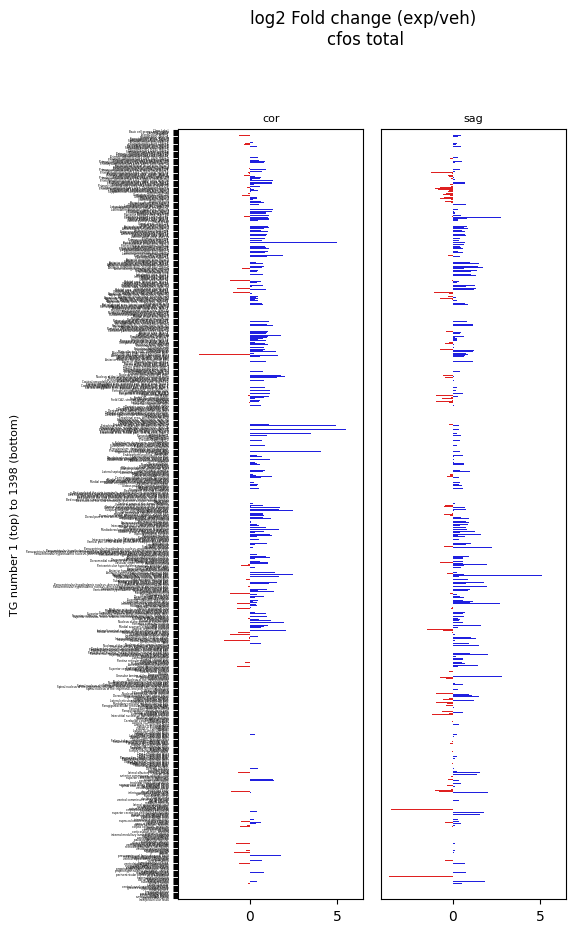

In [566]:
def draw_fold( _df_fold, _color):
    plt.clf()
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(5, 10), sharey=True, gridspec_kw={'wspace': 0.1})

    fig.suptitle(f'log2 Fold change (exp/veh) \n{_color}', fontsize=12, y=1.0)
    #fig.subplots_adjust(top= 2.0)
    
    _df_fold_color = _df_fold[_df_fold.columns[_df_fold.columns.to_series().str.endswith("_"+_color)]] 
    _df_fold_color.columns = ['cor','sag']
    
    colors = ['b' if e >= 0 else 'r' for e in _df_fold_color['cor'].values]
    
    g = sns.barplot(ax = ax1, data = _df_fold_color, y=_df_fold_color.index, x="cor", palette=colors)
    ax1.set_ylabel("")
    ax1.set_xlabel("")
    ax1.set_title('cor',fontsize=8)
    ax1.set_ylabel("TG number 1 (top) to 1398 (bottom)",fontsize=8)
    _index_ids = []
    _index_names = []
    for _i in range(len(_df_fold_color.index)):
        if _i % 2 == 0:
            _index_ids.append(_i)
            _index_names.append(list(_df_fold_color.index.values)[_i])
    
    ax1.set_yticks(_index_ids)
    ax1.set_yticklabels(_index_names, fontsize=2)
    ax1.tick_params(axis='y', labelright=False, right=False)
    
    
    colors = ['b' if e >= 0 else 'r' for e in _df_fold_color['sag'].values]
    sns.barplot(ax = ax2, data = _df_fold_color, y=_df_fold_color.index, x="sag",palette=colors, clip_on=False)
    ax2.set_title('sag',fontsize=8)
    ax2.set_ylabel("")
    ax2.set_xlabel("")
    ax2.set_yticks(_index_ids)
    ax2.set_yticklabels(_index_names, fontsize=2)
    ax2.tick_params(axis='y', labelleft=False, left=False, labelright=False, right=False)
    
    xmax = max(ax1.get_xlim()[1], ax2.get_xlim()[1])
    xmin = min(ax1.get_xlim()[0], ax2.get_xlim()[0])
    #xmax = max(np.quantile(_df_fold_color['sag'].values, 0.90),np.quantile(_df_fold_color['cor'].values, 0.90))
    
    ax1.set_xlim(xmax=xmax,xmin=xmin)
    ax2.set_xlim(xmax=xmax,xmin=xmin)
    #print(xmin,xmax)
    
    #plt.tight_layout()
    #plt.show()
    fig.savefig(f'/disk2/2024_mice/fold_{_color.replace("/","_").replace(" ","_")}.pdf', format='pdf', bbox_inches="tight")



#fig, axes = plt.subplots(1, 3,figsize=(15,10), sharey=True)

for _color_index, _color in enumerate(sorted(color_list)):
    logger.info(_color)
    draw_fold(_df_fold, _color)
#plt.show()
#plt.tight_layout()
#fig.savefig('output/boxplot.pdf')

In [569]:
status = subprocess.check_output('zip /disk2/2024_mice/fold.zip /disk2/2024_mice/fold_*', shell=True)
status = subprocess.check_output('cp /disk2/2024_mice/fold.zip output', shell=True)
print(status)

b''


<Figure size 640x480 with 0 Axes>

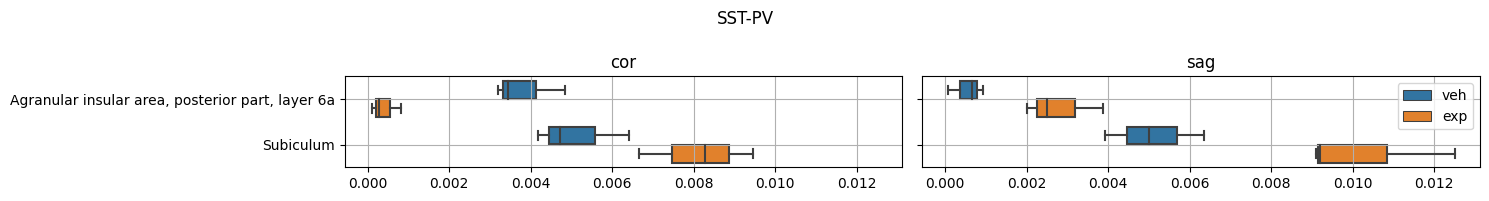

/tmp/ipykernel_3015095/386965231.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


<Figure size 640x480 with 0 Axes>

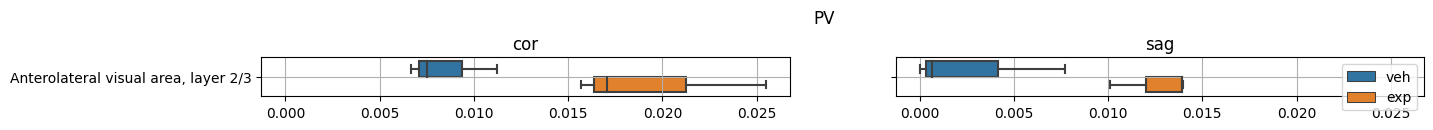

SST/cfos fraction


/tmp/ipykernel_3015095/386965231.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


<Figure size 640x480 with 0 Axes>

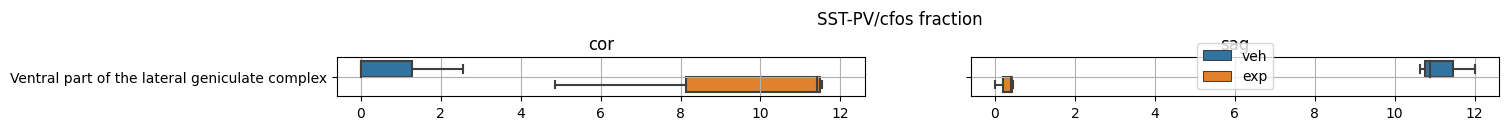

<Figure size 640x480 with 0 Axes>

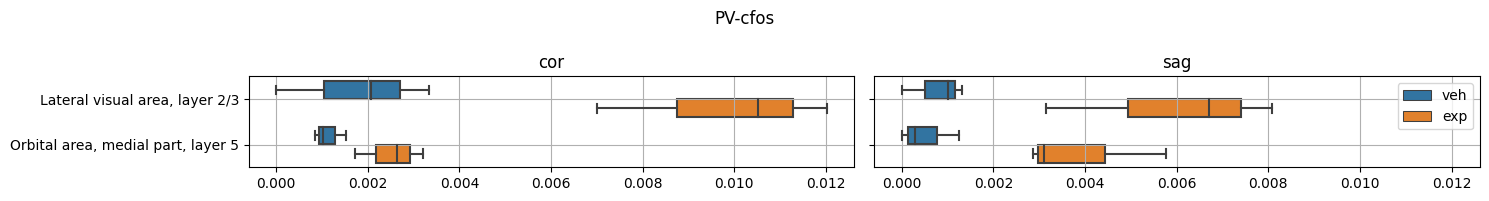

<Figure size 640x480 with 0 Axes>

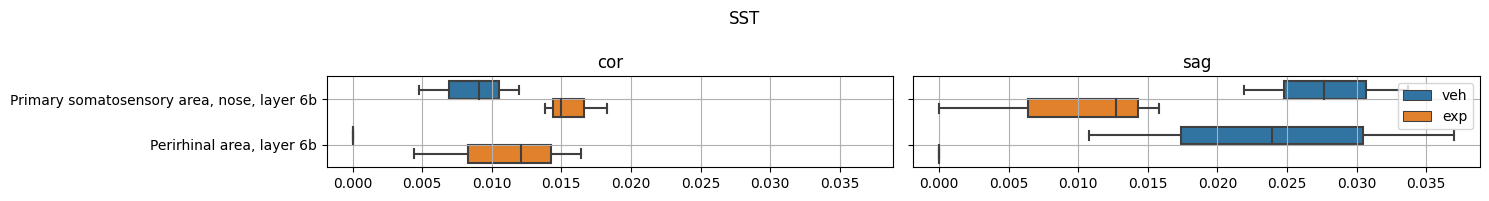

<Figure size 640x480 with 0 Axes>

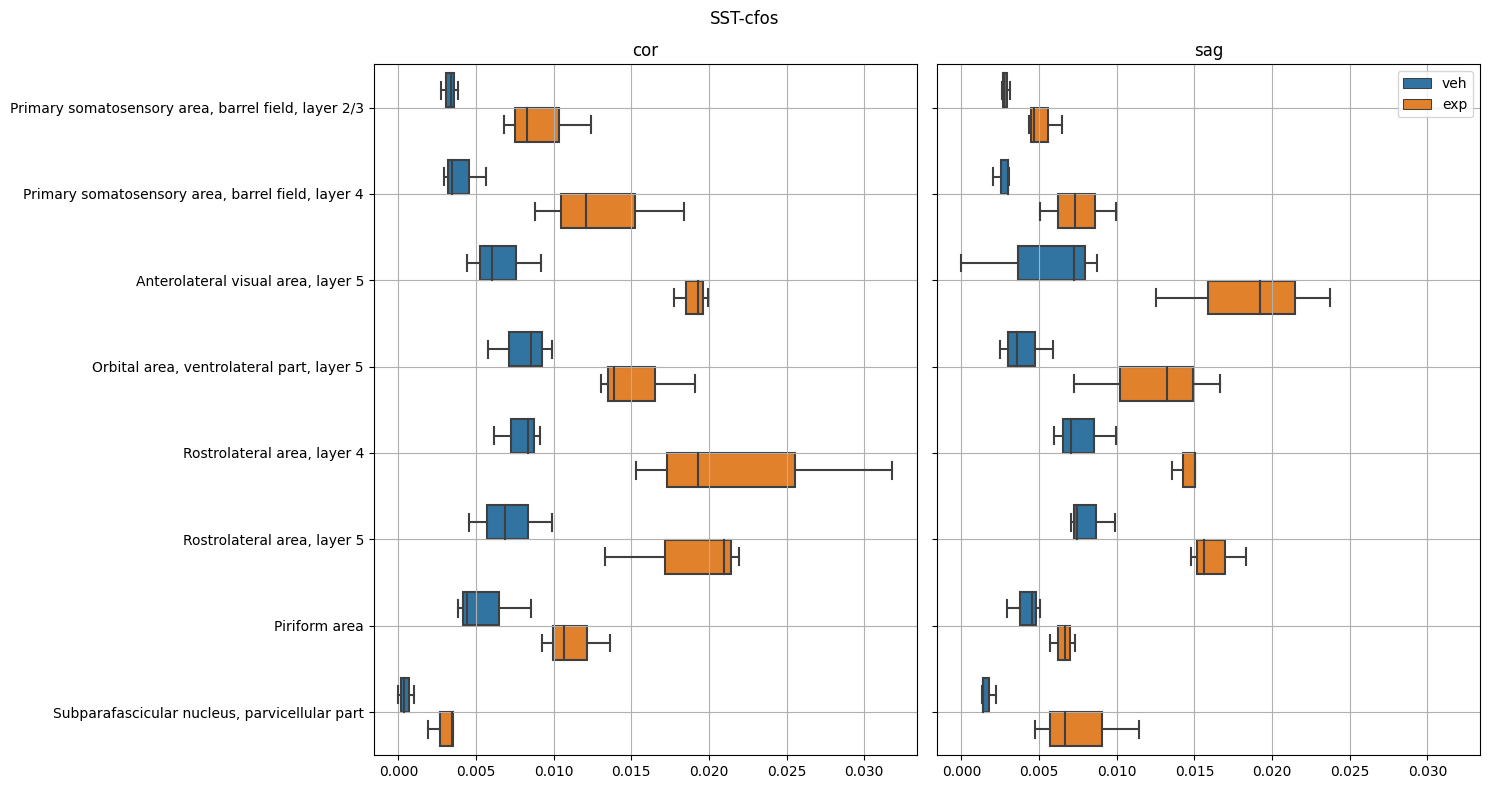

SST-PV-cfos


<Figure size 640x480 with 0 Axes>

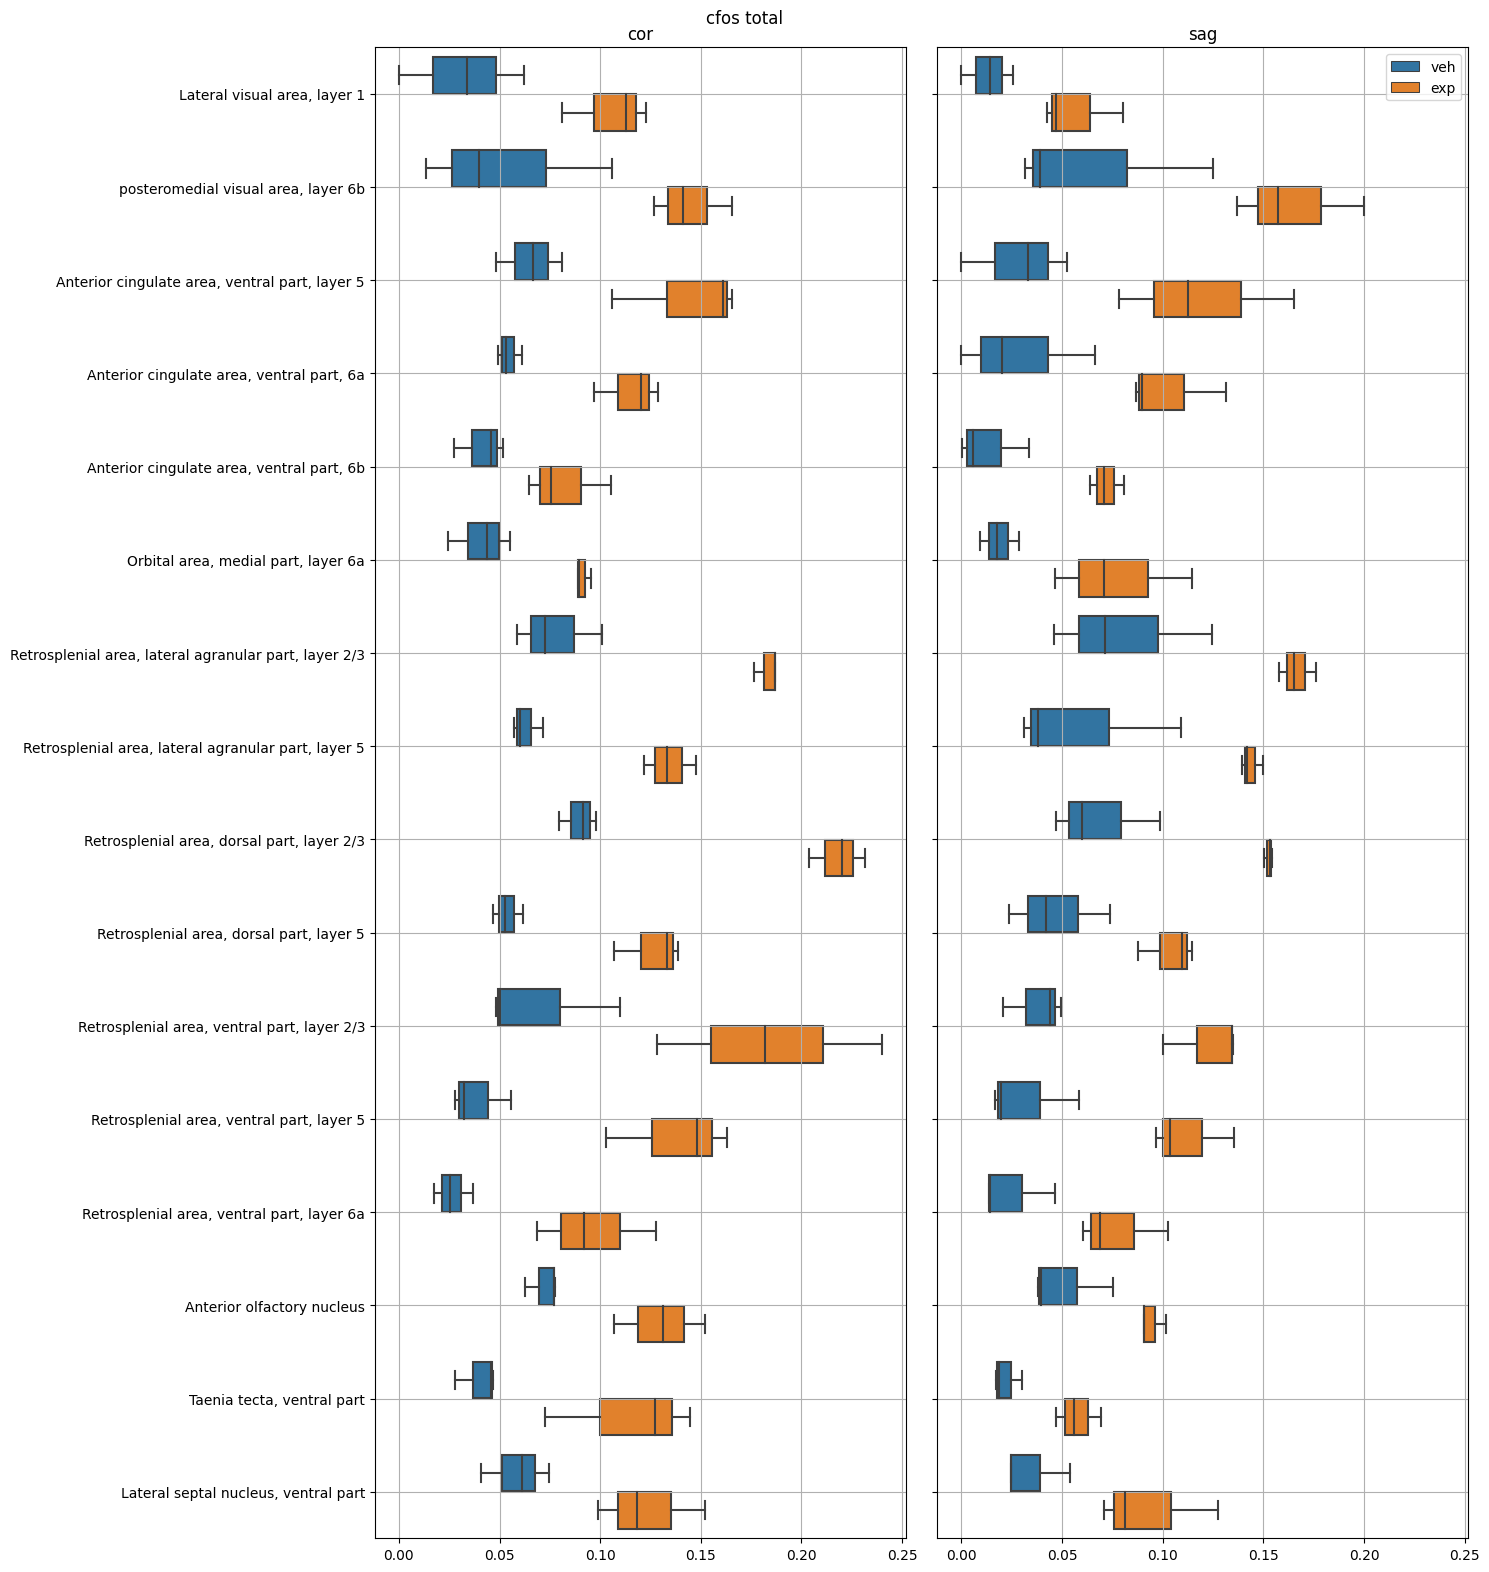

<Figure size 640x480 with 0 Axes>

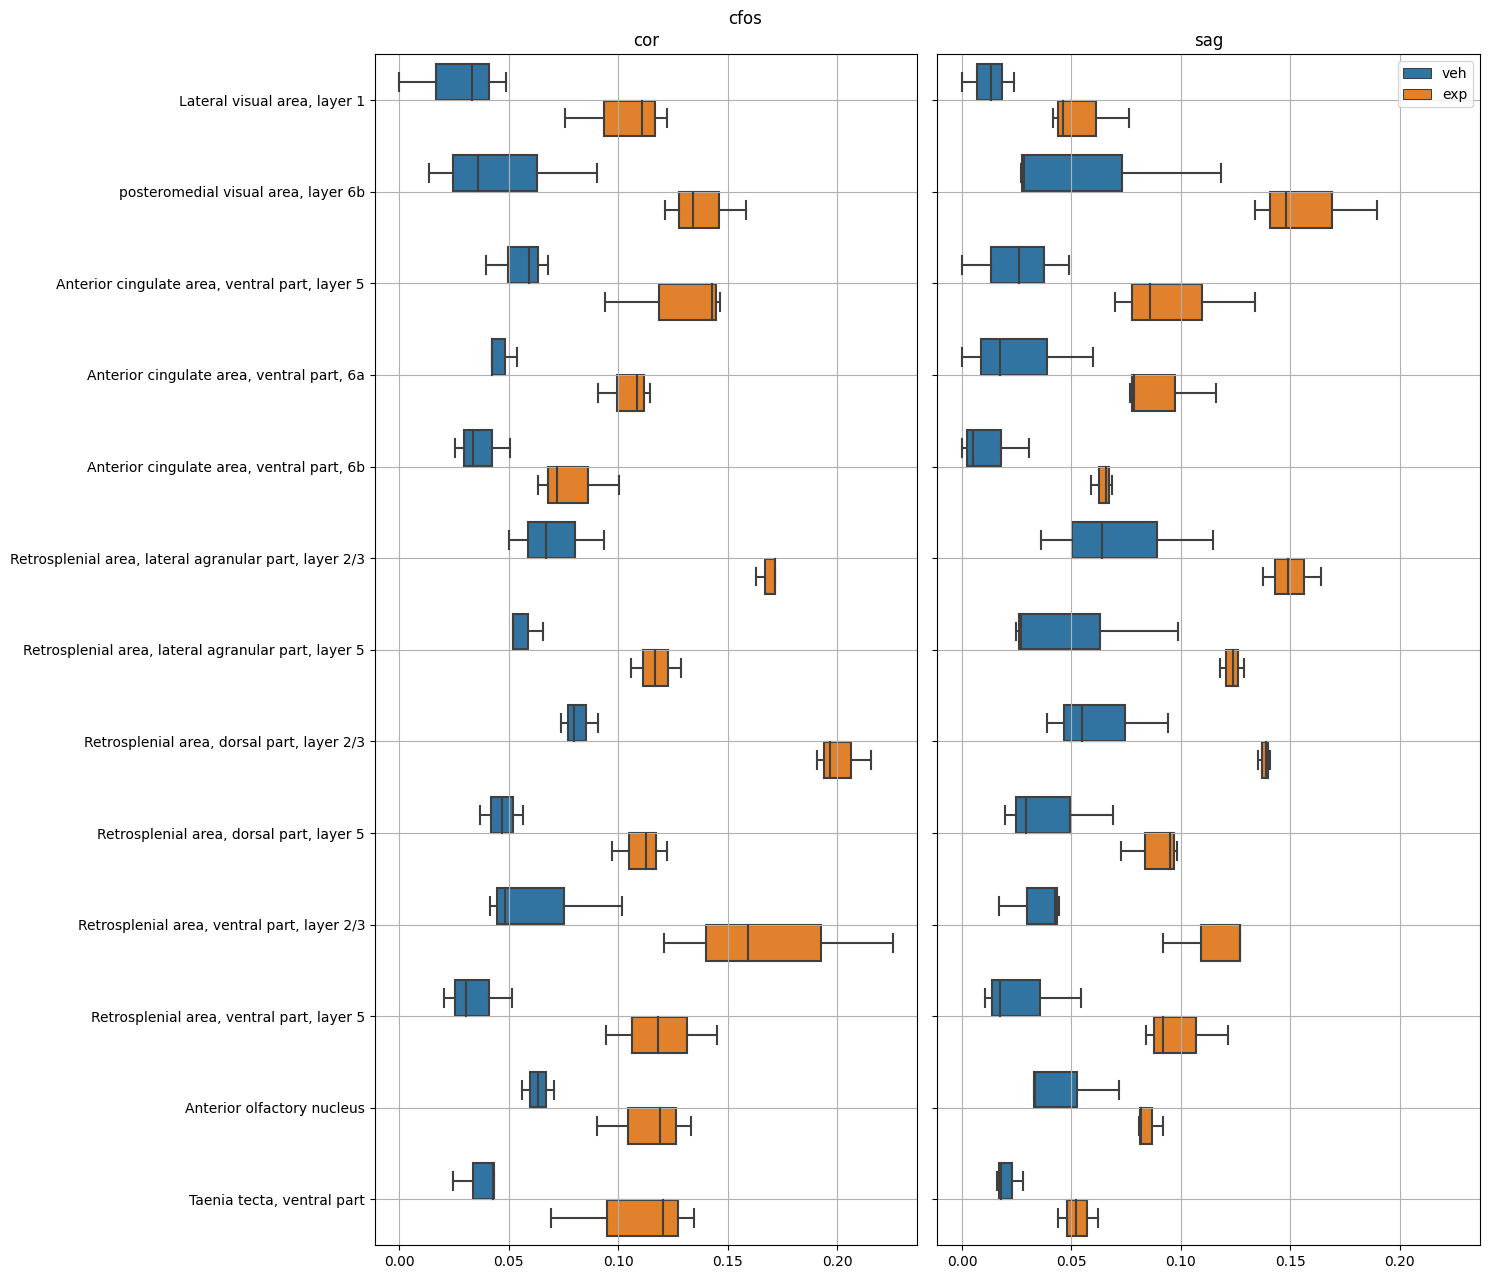

<Figure size 640x480 with 0 Axes>

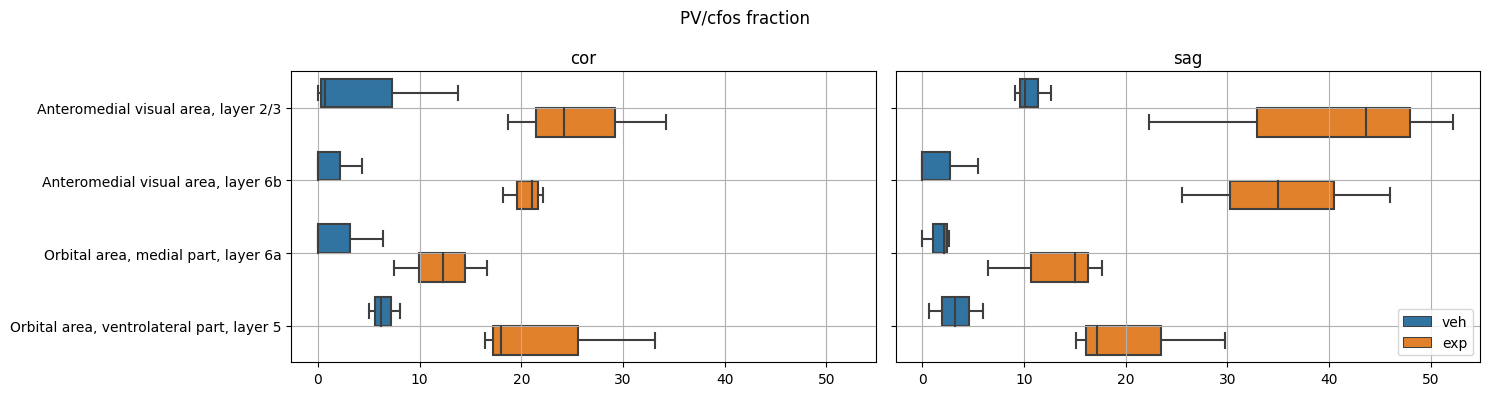

In [568]:
# box plot
_cut_method = 'cor'
min_pvalue = 0.05
#for _cut_method in cut_method_list:

for _color in color_list:

    _ttest_df_filtered = _ttest_df.query(f'color == "{_color}"')
    if len(_ttest_df_filtered) == 0:
        print(_color)
        continue
    _region_id_list = list(set(_ttest_df_filtered['tg_number'].values))
    _tg_number_list = []
    for _r, _g in _ttest_df_filtered.groupby('tg_number'):    
        if _g[_g['cut_method'] == 'cor']['pvalue'].values[0] <= min_pvalue and _g[_g['cut_method'] == 'sag']['pvalue'].values[0] <= min_pvalue:
            _tg_number_list.append(_g['tg_number'].values[0])
        #if True:
        #    break
    if len(_tg_number_list) == 0:
        print(_color)
        continue
    _cut_method = 'cor'
    _df = df_total[df_total.index.str.endswith(_cut_method+"_"+_color)]
    _df = _df[_tg_number_list + ['veh_exp']]
    _df_melt = pd.melt(_df, id_vars=['veh_exp'], value_vars=_tg_number_list)
    _df_melt['TG number'] = _df_melt['TG number'].replace(tg_2_name)
    
    

    plt.clf()  
    #fig = plt.figure(figsize=(10,len(_region_id_list)*1.0))
    fig, axes = plt.subplots(1, 2,figsize=(15,len(_tg_number_list)*1.0), sharey=True, sharex=True)
    fig.suptitle(_color)
    fig.subplots_adjust(top= 0.5)
    
    sns.boxplot(ax=axes[0], y = 'TG number', 
            x = 'value', 
            hue = 'veh_exp', data=_df_melt)
    axes[0].set(title =f'{_cut_method}' , xlabel='', ylabel=f'')
    axes[0].yaxis.grid(True) # Hide the horizontal gridlines
    axes[0].xaxis.grid(True) # Show the vertical gridlines
    #handles, labels = axes[0].get_legend_handles_labels()
    #axes[0].legend(handles, ['veh', 'exp'], title="") 

    axes[0].legend_ = None
    
    _cut_method = 'sag'
    _df = df_total[df_total.index.str.endswith(_cut_method+"_"+_color)]
    _df = _df[_tg_number_list + ['veh_exp']]
    _df_melt = pd.melt(_df, id_vars=['veh_exp'], value_vars=_tg_number_list)
    _df_melt['TG number'] = _df_melt['TG number'].replace(tg_2_name)
    
    sns.boxplot(ax=axes[1], y = 'TG number', 
            x = 'value', 
            hue = 'veh_exp', data=_df_melt)
    axes[1].set(title =f'{_cut_method}' , xlabel='', ylabel=f'')
    axes[1].yaxis.grid(True) # Hide the horizontal gridlines
    axes[1].xaxis.grid(True) # Show the vertical gridlines
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].legend(handles, ['veh', 'exp'], title="") 

    xmax = max(axes[0].get_xlim()[1], axes[1].get_xlim()[1])
    axes[0].set_xlim(xmax=xmax)
    axes[1].set_xlim(xmax=xmax)
    
    #plt.xticks(rotation=90)
    
    #fig.suptitle(f'{_region_id}\n', fontsize=15)
    #fig.tight_layout(h_pad=2.0)#reduces the horizontal gap
    #fig.savefig(f'output/box_{dept_col}.pdf', format='pdf', bbox_inches="tight")
    fig.tight_layout()
    fig.savefig(f'/disk2/2024_mice/boxplot_{_color.replace("/","_").replace(" ","_")}.pdf', format='pdf', bbox_inches="tight")
    plt.show()
    #if True:
    #    break


In [570]:
status = subprocess.check_output('zip /disk2/2024_mice/boxplot.zip /disk2/2024_mice/boxplot_*', shell=True)
status = subprocess.check_output('cp /disk2/2024_mice/boxplot.zip output', shell=True)
print(status)

b''


In [ ]:
df_exp = df_exp[df_exp[df_exp.columns[3:]].sum(axis=1) != 0.0]

In [ ]:
df_exp.loc[ df_exp.eq(0).sum(axis=1).index,'zero_count'] = df_exp.eq(0).sum(axis=1).values

In [ ]:
df_exp[[a for a in df_exp.columns if cut+"_"+color in a]].eq(0).sum(axis=1)

In [ ]:
_df_list = []
_df_columns = []
_df_list.append(df_exp[df_exp.columns[:3]])
_df_columns.extend(df_exp.columns[:3])
for cut in cut_method_list:
    for color in color_list:
        #_row = {}
        _df_columns.append(cut+"_"+color)
        _df_list.append(df_exp[[a for a in df_exp.columns if a.endswith(cut+"_"+color)]].eq(0).sum(axis=1))
        #_row_list.append(_row)
_df_zero_count = pd.concat(_df_list, axis=1)
_df_zero_count.columns = _df_columns
_df_zero_count

In [ ]:
_df_zero_count[(_df_zero_count == 3).sum(axis=1) != 0]

In [ ]:
import urllib.request, json 
with urllib.request.urlopen("http://api.brain-map.org/api/v2/structure_graph_download/1.json") as url:
    mouse_graph = json.load(url)
    #print(data)

In [ ]:
json.dumps(mouse_graph).strip()

In [ ]:
type(mouse_graph['msg'])

In [ ]:
import networkx as nx
G = nx.DiGraph()
def _traverse(G, _parent, _cur):
    #print(_root)

    _name = _cur['name']
    _id = int(_cur['id'])
    G.add_node(_id, name =_name)
    
    if _parent is not None:
        G.add_edge(int(_parent['id']), _id)

    
    if 'children' not in _cur:
        return
        
    _obj_list = _cur['children']
    for _obj in _obj_list:
        
        _traverse(G, _cur, _obj)

_traverse(G, None, mouse_graph['msg'][0])
G

In [ ]:
nx.ancestors(G, 68)

In [ ]:
nx.is_directed_acyclic_graph(G)

dict(nx.tree_all_pairs_lowest_common_ancestor(G, pairs=[(1, 4), (2, 3)]))

In [ ]:
#G.number_of_nodes()

for _c in G.neighbors(879):
    print(G.nodes[_c]['name'])

In [ ]:
from jsonpath_ng import jsonpath, parse
jsonpath_expr = parse('foo[*].baz')
[match.value for match in jsonpath_expr.find(mouse_graph)]

In [ ]:
for region_id in _df_zero_count['Region ID'].values:
    try:
        bg_atlas.structures[region_id]["name"]
        #pass
        #logger.info(f'{bg_atlas.structures[region_id]["name"]} / {bg_atlas.get_structure_ancestors(region_id)}')
    except:
        logger.error(f'{region_id}')

#bg_atlas.structures[567]['name']

In [ ]:
from pprint import pprint

import numpy as np

from brainglobe_atlasapi import BrainGlobeAtlas

bg_atlas = BrainGlobeAtlas("allen_mouse_25um", check_latest=False)

In [ ]:
type(bg_atlas.structures)

In [ ]:
for region_id in _df_zero_count['Region ID'].values:
    try:
        bg_atlas.structures[region_id]["name"]
        #pass
        #logger.info(f'{bg_atlas.structures[region_id]["name"]} / {bg_atlas.get_structure_ancestors(region_id)}')
    except:
        logger.error(f'{region_id}')

#bg_atlas.structures[567]['name']